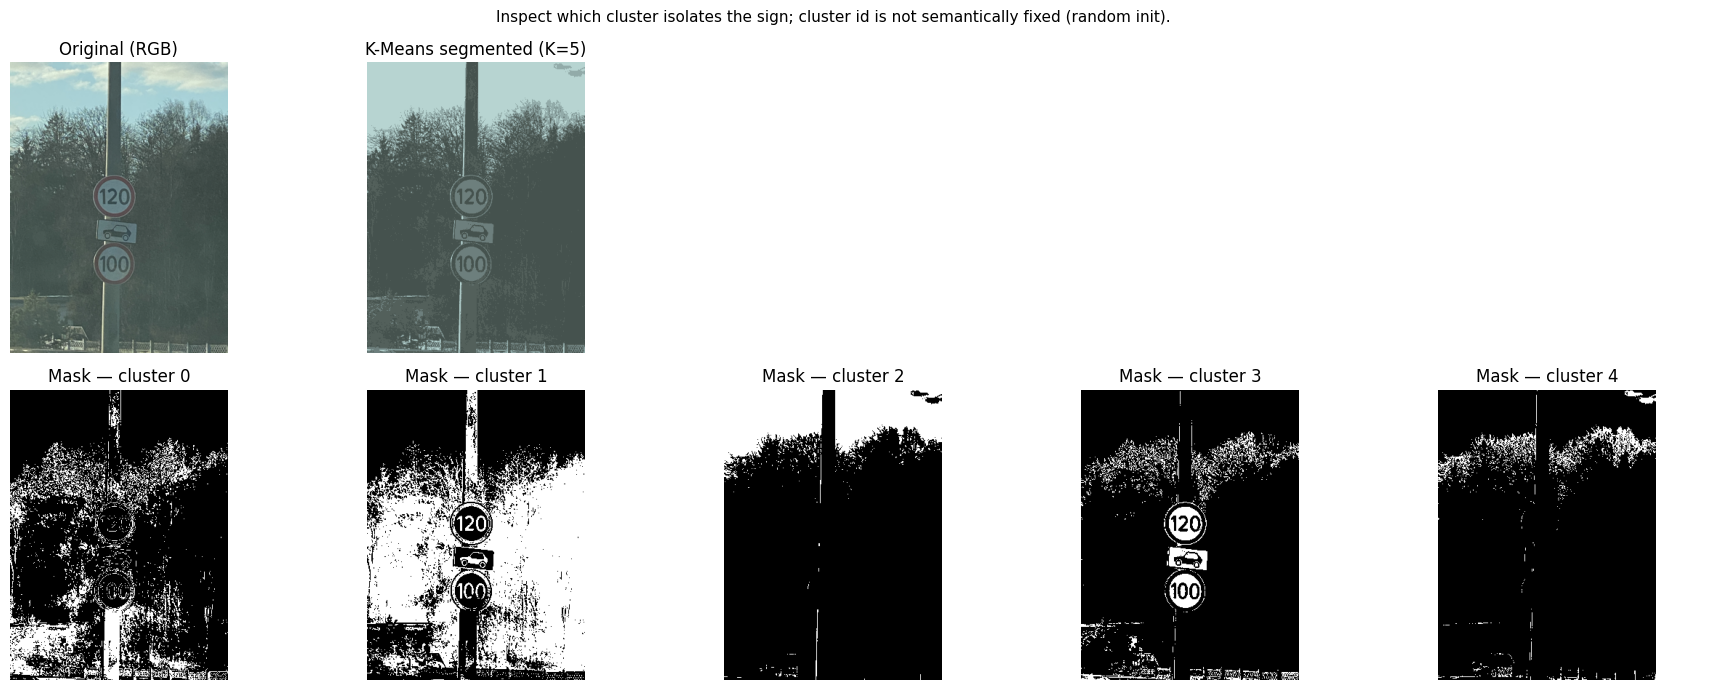

In [5]:
from __future__ import annotations

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------------------------
# K-Means image segmentation prototype — traffic sign pipeline
# Exploratory: use clusters instead of hardcoded HSV thresholds for
# lighting/shadow robustness. Cluster indices are not semantic (random init);
# pick the mask that isolates the sign by inspection or by center color.
# Tuning: if results are poor, try different K, or k-means in LAB/HSV
# (convert image, then reshape to (N, 3) the same way).
# ---------------------------------------------------------------------------


def _default_project_root() -> Path:
    """
    Find Traffic-Sign-Detection project root (folder containing detection/detection.py).
    In Jupyter, set the kernel's working directory to that folder, or set PROJECT_ROOT manually.
    """
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "detection" / "detection.py").is_file():
            return p
        p = p.parent
    return Path.cwd().resolve()


PROJECT_ROOT = _default_project_root()
# Annotations reference files like road125.png — point to data/raw, processed, etc.
IMAGE_PATH = PROJECT_ROOT / "data" / "raw" / "images" /"road700.png"

K = 5
# Standard termination: max 100 iterations, stop when center movement < 0.2
CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)


def load_image_bgr_to_rgb(path: str | Path) -> np.ndarray:
    """Load a file with OpenCV (BGR) and return RGB uint8 (H, W, 3) for matplotlib."""
    path = str(path)
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {path}. Set IMAGE_PATH to a real file (e.g. data/raw or data/processed)."
        )
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def reshape_image_to_kmeans_samples(
    image_rgb: np.ndarray,
) -> tuple[np.ndarray, tuple[int, int, int]]:
    """
    Reshape (H, W, 3) to (N, 3) float32 — required for cv2.kmeans on color samples.
    Returns (pixels, (H, W, C)) for mapping labels back to image shape.
    """
    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        raise ValueError("Expected a 3-channel color image (H, W, 3).")
    h, w, c = image_rgb.shape
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)
    return pixels, (h, w, c)


def run_kmeans_rgb(pixels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    K=5: e.g. sky, road, shadows, sign interior, sign border hues.
    Returns labels (N, 1) and centers (K, 3) in RGB.
    """
    _compactness, labels, centers = cv2.kmeans(
        pixels,
        K,
        None,
        CRITERIA,
        10,
        cv2.KMEANS_RANDOM_CENTERS,
    )
    return labels, centers


def reconstruct_quantized_image(
    labels: np.ndarray, centers: np.ndarray, shape_hwc: tuple[int, int, int]
) -> np.ndarray:
    """Replace each label with its cluster center color; uint8 (H, W, 3)."""
    h, w, c = shape_hwc
    centers_ = centers.reshape(-1, 3)
    flat = labels.reshape(-1)
    quantized = centers_[flat].reshape(h, w, c)
    return np.clip(quantized, 0, 255).astype(np.uint8)


def cluster_masks_from_labels(
    labels: np.ndarray, shape_hw: tuple[int, int]
) -> list[np.ndarray]:
    """One binary mask (0/255) per cluster k in 0..K-1."""
    h, w = shape_hw
    labels_2d = labels.reshape(h, w)
    return [(labels_2d == k).astype(np.uint8) * 255 for k in range(K)]


# --- Run pipeline
img_rgb = load_image_bgr_to_rgb(IMAGE_PATH)
pixels, shape_hwc = reshape_image_to_kmeans_samples(img_rgb)
h, w, _ = shape_hwc

labels, centers = run_kmeans_rgb(pixels)
segmented_rgb = reconstruct_quantized_image(labels, centers, shape_hwc)
masks = cluster_masks_from_labels(labels, (h, w))

# --- Visualization: original | segmented | five cluster masks (side by side)
fig, ax = plt.subplots(2, 5, figsize=(18, 7))

ax[0, 0].imshow(img_rgb)
ax[0, 0].set_title("Original (RGB)")
ax[0, 0].axis("off")

ax[0, 1].imshow(segmented_rgb)
ax[0, 1].set_title("K-Means segmented (K=5)")
ax[0, 1].axis("off")

for j in range(2, 5):
    ax[0, j].axis("off")

for k in range(5):
    ax[1, k].imshow(masks[k], cmap="gray", vmin=0, vmax=255)
    ax[1, k].set_title(f"Mask — cluster {k}")
    ax[1, k].axis("off")

plt.suptitle(
    "Inspect which cluster isolates the sign; cluster id is not semantically fixed (random init).",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# Optional: print(centers) to compare cluster center RGB across runs
